## 세상에 없는 얼굴 GAN 오토인코더

- 적대적 신경망 실행하기

실습: GAN 모델 만들기

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 28, 28, 1)      │       865,281 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       212,865 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,146 (4.11 MB)

 Trainable params: 852,609 (3.25 MB)

 Non-trainable params: 225,537 (881.00 KB)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\backend\tensorflow\trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


epoch:0 d_loss:2.6374 g_loss:0.7236
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
epoch:100 d_loss:2.4282 g_loss:0.5768
epoch:200 d_loss:2.5006 g_loss:0.5078
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
epoch:300 d_loss:2.5475 g_loss:0.4514
epoch:400 d_loss:2.6162 g_loss:0.4066
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:500 d_loss:2.6421 g_loss:0.3718
epoch:600 d_loss:2.6597 g_loss:0.3450
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:700 d_loss:2.6808 g_loss:0.3243
epoch:800 d_loss:2.6990 g_loss:0.3080
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
epoch:900 d_loss:2.7085 g_loss:0.2949
epoch:1000 d_loss:2.7340 g_loss:0.2841
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
epoch:1100 d_loss:2.7562 g_loss:0.2752
epoch:1200 d_loss:2.7611 g_loss:0.2677
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
epoch:1300 d_loss:2.7669 g_loss:0.2612
epoch:1400 d_loss:2.7779 g_loss:0.2557
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
epoch:1500 d_loss:2.7812 g_loss:0.2510
epoch:1600 d_loss:2.7888 g_loss:0.2468
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
epoch:

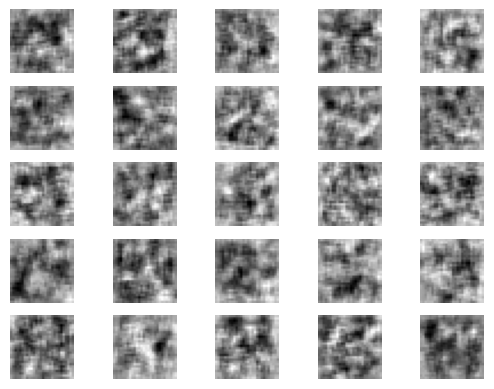

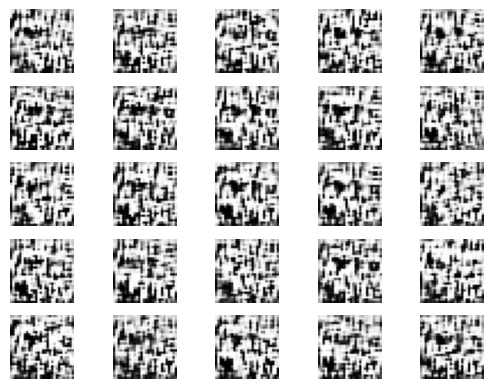

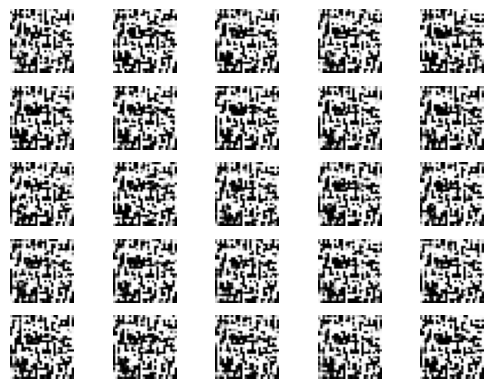

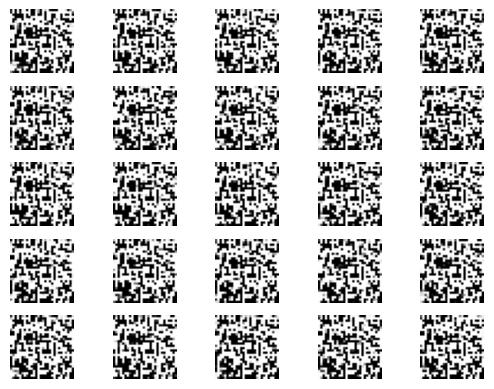

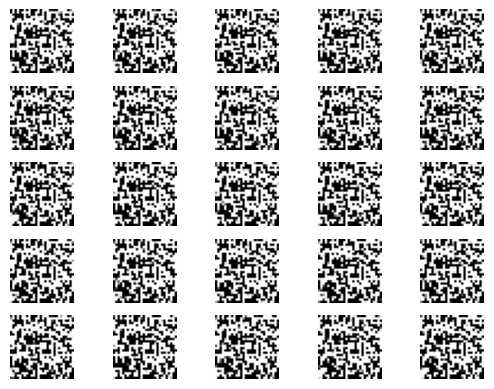

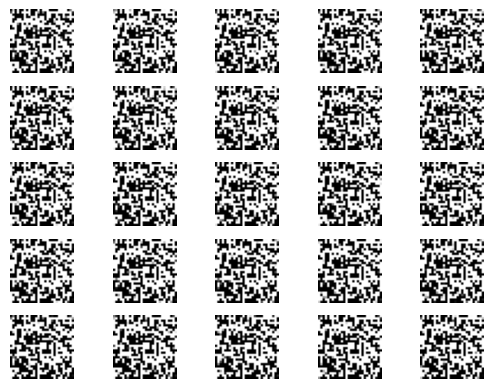

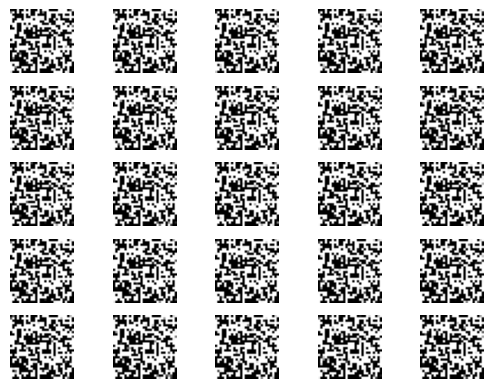

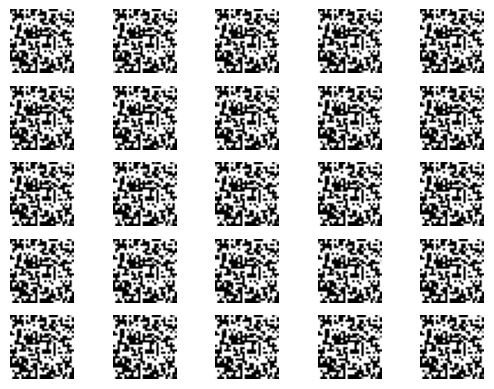

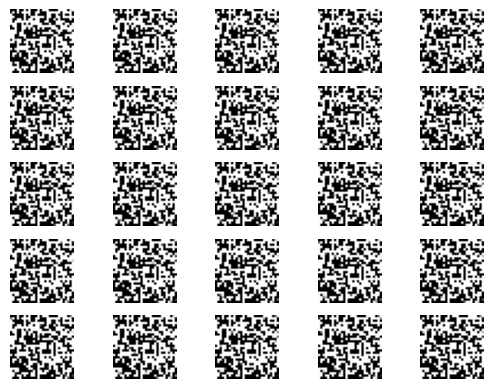

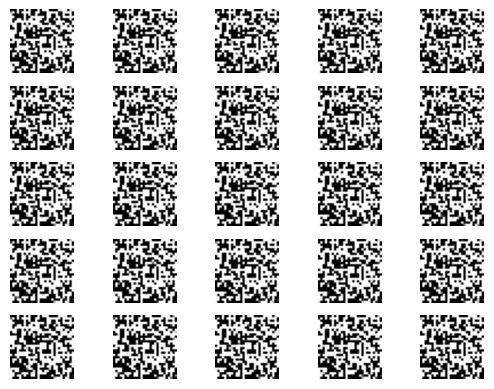

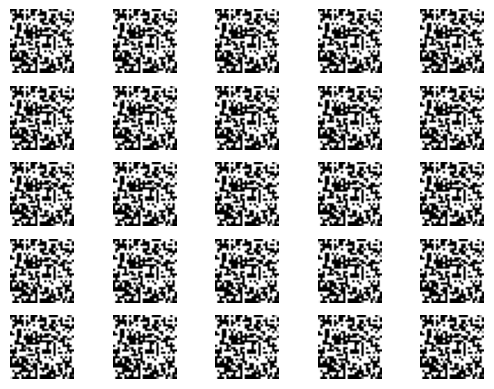

In [ ]:
# ================================
# 1️⃣ MNIST 데이터셋 불러오기
# ================================
# MNIST는 손글씨 숫자(0~9) 이미지 데이터셋
# 28×28 크기의 흑백 이미지 70,000장
# GAN에서 "진짜 이미지"로 사용됨
from tensorflow.keras.datasets import mnist

# ================================
# 2️⃣ 신경망 층(Layer)들 불러오기
# ================================

# Input        → 모델의 입력 정의
# Dense        → 일반적인 완전연결 신경망 (FC Layer)
# Reshape     → 1차원 벡터를 2D 이미지 형태로 바꿔줌
# Flatten     → 2D 이미지를 다시 1차원으로 펴줌
# Dropout     → 학습 중 일부 뉴런을 꺼서 과적합 방지
from tensorflow.keras.layers import Input,Dense,Reshape,Flatten,Dropout

# BatchNormalization → 데이터 분포를 정규화하여 학습을 안정화
# Activation         → 활성화 함수(ReLU, sigmoid 등) 적용
# LeakyReLU          → ReLU 개선 버전 (음수도 조금 통과시킴)
# UpSampling2D       → 이미지 크기를 키움 (7×7 → 14×14 같은 식)
# Conv2D             → 이미지 처리용 합성곱 필터
from tensorflow.keras.layers import BatchNormalization,Activation,LeakyReLU,UpSampling2D,Conv2D


# ================================
# 3️⃣ 모델 구조 만들기 도구
# ================================

# Sequential → 층을 위에서 아래로 차곡차곡 쌓는 모델
# Model      → GAN처럼 복잡한 구조(입력 여러 개, 출력 여러 개)에 사용
from tensorflow.keras.models import Sequential,Model


# ================================
# 4️⃣ 수학 계산을 위한 NumPy
# ================================

# 벡터, 행렬, 난수 생성 등
# GAN에서 랜덤 노이즈(z) 만들 때 사용
import numpy as np

# ================================
# 5️⃣ 이미지 & 그래프 출력
# ================================

# 생성된 숫자 이미지 출력
# 학습 과정의 손실(loss) 그래프 시각화
import matplotlib.pyplot as plt

# ===============================
# 1️⃣ 생성자 모델 생성
# ===============================
# Sequential → 층을 위에서 아래로 순서대로 쌓는 모델
generator=Sequential()


# ------------------------------------
# 1️⃣ 랜덤 숫자 100개 → 큰 벡터로 변환
# ------------------------------------
# input_dim=100 → 랜덤한 숫자 100개를 입력으로 받음 (노이즈)
# 128*7*7 = 6272 → 나중에 7×7×128 이미지로 바꾸기 위한 크기
# LeakyReLU(0.2) → 음수도 조금 살려서 학습이 잘 되게 함
generator.add(Dense(128*7*7,
                    input_dim=100,
                    activation=LeakyReLU(0.2)))


# BatchNormalization → 값들을 정규화해서 학습이 안정되게 함
generator.add(BatchNormalization())


# BatchNormalization:
# → 각 배치의 평균을 0, 분산을 1로 맞춤
# → 학습을 안정화하고 GAN에서 특히 중요

# ------------------------------------
# 2️⃣ 1차원 숫자 → 3차원 이미지 형태로 변경
# ------------------------------------
# (6272,) → (7, 7, 128)
# 즉, 128장의 7×7 작은 이미지로 바꾼 것
generator.add(Reshape((7,7,128)))


# ------------------------------------
# 3️⃣ 이미지 크기 키우기 (7×7 → 14×14)
# ------------------------------------
# UpSampling2D → 가로 세로 크기를 2배로 키움
generator.add(UpSampling2D())


# ------------------------------------
# 4️⃣ CNN으로 이미지 다듬기
# ------------------------------------
# Conv2D(64) → 64개의 필터로 이미지 특징을 만들어냄
# kernel_size=5 → 5×5 필터 사용
# padding='same' → 이미지 크기 유지
generator.add(Conv2D(64,
                     kernel_size=5, 
                     padding='same')) 



# ===============================
# 7️⃣ 다시 배치 정규화
# ===============================
generator.add(BatchNormalization())


# 다시 LeakyReLU 활성화 함수 적용
generator.add(Activation(LeakyReLU(0.2)))

# Conv2D 뒤에 활성화 함수 적용
# → 비선형성을 추가해서 더 복잡한 패턴 생성 가능

# ------------------------------------
# 5️⃣ 다시 이미지 크기 키우기 (14×14 → 28×28)
# ------------------------------------
generator.add(UpSampling2D())


# ------------------------------------
# 6️⃣ 최종 이미지 생성 (MNIST 크기)
# ------------------------------------
# Conv2D(1) → 흑백 이미지니까 채널 1개
# tanh → 출력값을 -1 ~ 1 범위로 제한
# → GAN에서 이미지 픽셀값을 만들 때 많이 사용
generator.add(Conv2D(1,kernel_size=5,padding='same',activation='tanh'))



# ================================
# 🕵️ GAN의 Discriminator (진짜인지 가짜인지 판단하는 신경망)
# ================================

# 여러 층을 순서대로 쌓는 모델 생성
discriminator=Sequential()

# ------------------------------------
# 1️⃣ 첫 번째 CNN 층
# ------------------------------------
# 입력 이미지 크기: (28, 28, 1)
# → MNIST 숫자 이미지 (28×28 흑백)
#
# Conv2D(64) → 64개의 필터로 이미지 특징을 찾음
# kernel_size=5 → 5×5 필터 사용
# strides=2 → 가로·세로를 절반으로 줄임 (28 → 14)
# padding='same' → 가장자리 잘리지 않게 처리
discriminator.add(Conv2D(64,kernel_size=5,strides=2,input_shape=(28,28,1),padding='same'))

# LeakyReLU → 작은 음수도 살려서 학습이 잘 되게 함
discriminator.add(Activation(LeakyReLU(0.2)))

# Dropout(0.3) → 뉴런 30%를 랜덤으로 끔
# → 판별자가 너무 똑똑해지는 것을 막음 (과적합 방지)
discriminator.add(Dropout(0.3))

# ------------------------------------
# 2️⃣ 두 번째 CNN 층 (더 깊은 특징 추출)
# ------------------------------------
# 64채널 → 128채널
# 이미지 크기: 14×14 → 7×7
discriminator.add(Conv2D(128,kernel_size=5,strides=2,padding='same'))

# 다시 LeakyReLU
discriminator.add(Activation(LeakyReLU(0.2)))

# 다시 Dropout으로 과적합 방지
discriminator.add(Dropout(0.3))

# ------------------------------------
# 3️⃣ CNN 결과를 1차원으로 펼침
# ------------------------------------
# (7,7,128) → (7×7×128 = 6272개 숫자)
# Dense층에 넣기 위해 일렬로 펼침
discriminator.add(Flatten())

# ------------------------------------
# 4️⃣ 진짜인지 가짜인지 판단
# ------------------------------------
# Dense(1) → 결과 하나만 출력
# sigmoid → 0~1 사이 값
#   1에 가까우면 "진짜"
#   0에 가까우면 "가짜"
discriminator.add(Dense(1,activation='sigmoid'))

# ------------------------------------
# 5️⃣ 판별자 학습 설정
# ------------------------------------
# binary_crossentropy → 진짜/가짜 (2분류) 손실 함수
# adam → 가장 많이 쓰이는 최적화 방법
discriminator.compile(loss='binary_crossentropy',optimizer='adam')

# ------------------------------------
# 6️⃣ GAN 학습을 위한 중요한 설정
# ------------------------------------
# discriminator.trainable = False
# → GAN 전체를 학습할 때
#   판별자는 고정하고
#   Generator만 학습시키기 위해 사용
discriminator.trainable=False

# -----------------------------------------
# GAN의 입력(Generator로 들어갈 입력) 만들기
# -----------------------------------------
# shape=(100,) → 100개의 랜덤 숫자를 하나의 묶음으로 받음
# 이 100개 숫자가 Generator의 재료(노이즈)가 됨
ginput=Input(shape=(100,))


# -----------------------------------------
# Generator + Discriminator 연결
# -----------------------------------------
# ginput → Generator → 가짜 이미지 생성
# 가짜 이미지 → Discriminator → 진짜인지 가짜인지 판별
#
# 즉, 이 한 줄은 아래를 의미함:
# dis_output = Discriminator( Generator(랜덤숫자 100개) )
dis_output=discriminator(generator(ginput))

# -----------------------------------------
# GAN 모델 생성
# -----------------------------------------
# 입력: 랜덤숫자 100개
# 출력: Discriminator가 판단한 진짜/가짜 값 (0~1)
# 이 전체를 하나의 모델로 만듦
gan=Model(ginput,dis_output)

# -----------------------------------------
# GAN 학습 규칙 설정
# -----------------------------------------
# loss='binary_crossentropy'
#   → 진짜(1) vs 가짜(0) 구분용 손실 함수
# optimizer='adam'
#   → 자동으로 가중치를 잘 조정해 주는 알고리즘
gan.compile(loss='binary_crossentropy',optimizer='adam')

# -----------------------------------------
# GAN 전체 구조 출력
# -----------------------------------------
# Generator → Discriminator로 이어진 구조를 표로 보여줌
gan.summary()


def gan_train(epoch,batch_size,saving_intereval):

    # epoch → GAN이 몇 번 싸울지
    # batch_size → 한 번에 몇 장의 그림을 사용할지
    # saving_interval → 몇 번마다 그림을 저장할지

    # ------------------------------------
    # 1️⃣ MNIST 진짜 손글씨 숫자 불러오기
    # ------------------------------------
    (X_train,_),(_,_)=mnist.load_data()
     # X_train에는 28×28짜리 숫자 이미지들이 들어 있음
    X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32')
    # CNN에 넣기 좋게 모양 바꾸기
    # (개수, 28, 28) → (개수, 28, 28, 1)

    # X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

    
    # ------------------------------------
    # 2️⃣ 판별자에게 줄 정답 만들기
    # ------------------------------------
    true=np.ones((batch_size,1))  # 진짜 이미지의 정답 → 1
    fake=np.zeros((batch_size,1)) # 가짜 이미지의 정답 → 0

    
    # ------------------------------------
    # 3️⃣ GAN 학습 반복 시작
    # ------------------------------------
    for i in range(epoch):
        # ----------------------------
        # 3-1️⃣ 진짜 이미지 선택
        # ----------------------------
        # MNIST에서 랜덤으로 batch_size만큼 뽑기
        idx=np.random.randint(0,X_train.shape[0],batch_size)
        imgs=X_train[idx]
        # 판별자에게 진짜 이미지와 정답(1)을 주고 학습
        d_loss_real=discriminator.train_on_batch(imgs,true)

        # ----------------------------
        # 3-2️⃣ 가짜 이미지 만들기
        # ----------------------------
        # Generator에 넣을 랜덤 숫자 100개 생성
        noise=np.random.normal(0,1,(batch_size,100))
         # Generator가 가짜 숫자 이미지 생성
        gen_imgs=generator.predict(noise,verbose=0)

        # ----------------------------
        # 3-3️⃣ 가짜 이미지로 판별자 학습
        # ----------------------------
        # 판별자에게 "이건 가짜야(0)" 라고 알려주고 학습
        d_loss_fake=discriminator.train_on_batch(gen_imgs,fake)

        # ----------------------------
        # 3-4️⃣ 판별자 전체 손실 계산
        # ----------------------------
        # 진짜와 가짜에 대한 오차 평균
        d_loss=0.5*np.add(d_loss_real,d_loss_fake)
        # ----------------------------
        # 3-5️⃣ Generator 학습 (핵심!)
        # ----------------------------
        # Generator에게:
        # "네가 만든 가짜 이미지를
        # 판별자가 진짜(1)라고 믿게 만들어라!"
        g_loss=gan.train_on_batch(noise,true)
        # ----------------------------
        # 3-6️⃣ 학습 상태 출력
        # ----------------------------
        if i%100==0:
            print('epoch:%d' % i,'d_loss:%.4f' % d_loss,'g_loss:%.4f' % g_loss)
        
        # ----------------------------
        # 3-7️⃣ 가짜 이미지 저장
        # ----------------------------
        if i % saving_intereval==0:
             # 가짜 이미지 25장 만들기
            noise=np.random.normal(0,1,(25,100))
            gen_imgs=generator.predict(noise)

            # tanh(-1~1) → 0~1 범위로 변환
            gen_imgs=0.5*gen_imgs+0.5

            # 5×5 칸 그림판 만들기
            fig,axs=plt.subplots(5,5)
            count=0
             # 각 칸에 가짜 숫자 하나씩 그림
            for j in range(5):
                for k in range(5):
                    axs[j,k].imshow(gen_imgs[count,:,:,0],cmap='gray')
                    axs[j,k].axis('off')
                    count +=1
             # 그림 파일로 저장
            fig.savefig('./gan_mnist_%d.png' % i)


# ------------------------------------
# GAN 학습 시작
# ------------------------------------
# 2001번 반복
# 한 번에 32장
# 200번마다 그림 저장
gan_train(2001,32,200)

In [ ]:
# -------------------------------------------
# 1️⃣ MNIST 손글씨 숫자 데이터 불러오기
# -------------------------------------------
# MNIST는 0~9까지 손으로 쓴 숫자 이미지 데이터
# 각 이미지는 28×28 크기의 흑백 그림
from tensorflow.keras.datasets import mnist

# -------------------------------------------
# 2️⃣ 딥러닝 모델을 만들기 위한 도구
# -------------------------------------------
# Sequential → 층을 위에서 아래로 차례대로 쌓는 모델
# Model → 입력과 출력이 자유로운 복잡한 구조(GAN, AutoEncoder 등)에 사용
from tensorflow.keras.models import Sequential,Model

# -------------------------------------------
# 3️⃣ 신경망 층(레이어)들
# -------------------------------------------
# Input        → 모델에 들어오는 입력값 정의
# Dense        → 일반적인 완전연결 신경망
# Conv2D       → 이미지에서 특징을 찾아내는 필터
# MaxPooling2D → 이미지 크기를 줄여 중요한 특징만 남김
# UpSampling2D → 이미지 크기를 키움
# Flatten     → 이미지를 숫자 한 줄로 펴기
# Reshape     → 숫자 한 줄을 다시 이미지 모양으로 바꾸기
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,UpSampling2D,Flatten,Reshape

# -------------------------------------------
# 4️⃣ 그래프와 이미지를 보여주는 도구
# -------------------------------------------
# 학습 결과나 숫자 이미지를 화면에 보여줄 때 사용
import matplotlib.pyplot as plt


# -------------------------------------------
# 5️⃣ 수학 계산과 배열을 다루는 도구
# -------------------------------------------
# 딥러닝에서 숫자 계산, 랜덤 숫자 생성 등에 사용
import numpy as np


# -------------------------------------------
# 6️⃣ MNIST 데이터 불러오기
# -------------------------------------------
# X_train → 학습용 손글씨 숫자 이미지
# X_test  → 테스트용 손글씨 숫자 이미지
# _       → 정답(0~9 숫자)인데 지금은 사용하지 않아서 버림
(X_train,_),(X_test,_)=mnist.load_data()

# -------------------------------------------
# 7️⃣ 학습용 이미지 모양 바꾸기 + 정규화
# -------------------------------------------
# 원래 MNIST 이미지 모양: (60000, 28, 28)
# CNN에 넣기 위해 (60000, 28, 28, 1)로 변경
# 1은 흑백 채널(색깔이 1개라는 뜻)
# 숫자를 소수점 형태(float32)로 바꿔서 계산이 잘 되게 함
X_train=X_train.reshape(X_train.shape[0],28,28,1).astype('float32')/255

# X_test의 모양을 CNN이 쓸 수 있게 바꿈
# 원래: (10000, 28, 28)
# 변경: (10000, 28, 28, 1)
# → 마지막의 1은 "흑백 채널 1개"라는 뜻
# 이미지 픽셀값을 정수 → 소수(float)로 바꿈
# 딥러닝은 소수 계산이 더 정확하고 안정적이기 때문
# 픽셀값 범위를 0~255 → 0~1로 줄임
# 예: 0은 0, 255는 1
# → 학습과 예측이 훨씬 잘 되도록 만드는 중요한 작업
X_test=X_test.reshape(X_test.shape[0],28,28,1).astype('float32')/255


# ================================
# 🧠 오토인코더(AutoEncoder) 만들기
# ================================
# AutoEncoder는
# "이미지를 작게 압축했다가 다시 원래대로 복원하는 AI"입니다.
# → 숫자 그림을 작게 접었다가 다시 펼치는 기계라고 생각하면 됨.

autoencoder=Sequential()  # 층을 순서대로 쌓는 모델 생성


# ============================================================
# 🔽 Encoder (이미지 압축하는 부분)
# ============================================================

# -----------------------------------------
# 1️⃣ 첫 번째 CNN 층
# -----------------------------------------
# 입력 이미지: 28×28 흑백 숫자
# Conv2D(16) → 16개의 필터로 이미지 특징 추출
# kernel_size=3 → 3×3 크기의 필터 사용
# padding='same' → 이미지 크기 유지
# relu → 중요한 특징만 살리는 활성화 함수
autoencoder.add(Conv2D(16,kernel_size=3,padding='same',input_shape=(28,28,1),activation='relu'))

# -----------------------------------------
# 2️⃣ 이미지 크기 절반으로 줄이기
# -----------------------------------------
# MaxPooling2D(2) → 가로, 세로를 1/2로 줄임
# 28×28 → 14×14
# 중요한 정보만 남기고 압축
autoencoder.add(MaxPooling2D(pool_size=2,padding='same'))

# -----------------------------------------
# 3️⃣ 두 번째 CNN 층
# -----------------------------------------
# 16개 → 8개 필터
# → 더 중요한 특징만 남김
autoencoder.add(Conv2D(8,kernel_size=3,activation='relu',padding='same'))


# -----------------------------------------
# 4️⃣ 다시 크기 줄이기
# -----------------------------------------
# 14×14 → 7×7
autoencoder.add(MaxPooling2D(pool_size=2,padding='same'))


# -----------------------------------------
# 5️⃣ 마지막 압축 단계
# -----------------------------------------
# strides=2 → 이미지 크기를 또 반으로 줄임
# 7×7 → 4×4
# → 이것이 "압축된 핵심 정보"
autoencoder.add(Conv2D(8,kernel_size=3,strides=2,padding='same',activation='relu'))



# =====================================================
# 🔼 Decoder (압축된 이미지를 다시 원래대로 복원)
# =====================================================

# -----------------------------------------
# 1️⃣ 압축된 특징을 먼저 다듬기
# -----------------------------------------
# Conv2D(8) → 8개의 필터로
# 압축된 작은 그림의 특징을 다시 정리
# → 흐릿한 정보를 더 또렷하게 만듦
autoencoder.add(Conv2D(8,kernel_size=3,padding='same',activation='relu'))


# -----------------------------------------
# 2️⃣ 이미지 크기 키우기 (1단계)
# -----------------------------------------
# UpSampling2D → 가로·세로 크기를 2배로 키움
# 예) 4×4 → 8×8
# → 작은 그림을 크게 펼치기 시작
autoencoder.add(UpSampling2D())

# -----------------------------------------
# 3️⃣ 커진 그림을 다시 다듬기
# -----------------------------------------
# 크기만 키우면 흐릿하므로
# Conv2D로 다시 선과 모양을 또렷하게 만듦
autoencoder.add(Conv2D(8,kernel_size=3,padding='same',activation='relu'))

# -----------------------------------------
# 4️⃣ 이미지 크기 키우기 (2단계)
# -----------------------------------------
# 8×8 → 16×16
autoencoder.add(UpSampling2D())

# -----------------------------------------
# 5️⃣ 더 많은 필터로 세밀하게 복원
# -----------------------------------------
# 16개의 필터 사용 → 더 자세한 정보 복원
# → 숫자의 곡선, 두께 등을 더 정확히 표현
autoencoder.add(Conv2D(16,kernel_size=3,activation='relu'))

# -----------------------------------------
# 6️⃣ 이미지 크기 키우기 (3단계)
# -----------------------------------------
# 16×16 → 32×32
# → 거의 원래 MNIST 크기와 비슷
autoencoder.add(UpSampling2D())

# -----------------------------------------
# 7️⃣ 최종 숫자 이미지 만들기
# -----------------------------------------
# Conv2D(1) → 흑백 이미지니까 채널 1개
# sigmoid → 픽셀값을 0~1 사이로 제한
# → 실제 숫자 이미지처럼 보이게 만듦
autoencoder.add(Conv2D(1,kernel_size=3,padding='same',activation='sigmoid'))



# -----------------------------------------
# 8️⃣ 모델 구조 확인
# -----------------------------------------
# 각 층의 출력 크기와 파라미터 개수를 표로 보여줌
autoencoder.summary()

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0832 - val_loss: 0.0819
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.0829 - val_loss: 0.0822
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 0.0828 - val_loss: 0.0818
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - loss: 0.0827 - val_loss: 0.0816
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - loss: 0.0826 - val_loss: 0.0815
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - loss: 0.0825 - val_loss: 0.0814
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - loss: 0.0825 - val_loss: 0.0815
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 0.0823 - val_loss: 0.0818
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0822 - val_loss: 0.0811
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0821 - val_loss: 0.0810
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0820 - val_loss: 0.0809
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━

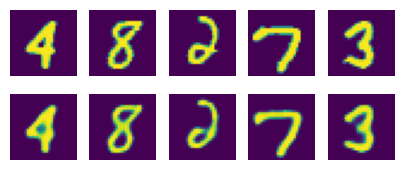

In [8]:
# -----------------------------------------
# 1️⃣ 오토인코더 학습 규칙 설정
# -----------------------------------------
# optimizer='adam'
# → 가중치를 자동으로 잘 조절해주는 똑똑한 학습 방법
# loss='binary_crossentropy'
# → 원본 이미지와 복원된 이미지가 얼마나 다른지 계산하는 공식
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

# -----------------------------------------
# 2️⃣ 오토인코더 학습 시작
# -----------------------------------------
# X_train → 입력 이미지
# X_train → 정답 이미지 (자기 자신을 다시 맞추는 구조)
# epochs=50 → 전체 데이터를 50번 반복 학습
# batch_size=128 → 한 번에 128장씩 학습
# validation_data → 시험용 데이터 (학습 상태 확인용)
autoencoder.fit(X_train,X_train,epochs=50,batch_size=128,validation_data=(X_test,X_test))

# -----------------------------------------
# 3️⃣ 테스트용 이미지 중 5개 랜덤 선택
# -----------------------------------------
# X_test.shape[0] → 테스트 이미지 개수
# size=5 → 그중 5개 랜덤 선택
random_test=np.random.randint(X_test.shape[0], size=5)

# -----------------------------------------
# 4️⃣ 오토인코더로 모든 테스트 이미지 복원
# -----------------------------------------
# ae_imgs → 오토인코더가 다시 그린 이미지들
ae_imgs=autoencoder.predict(X_test)

# -----------------------------------------
# 5️⃣ 그림을 그릴 큰 판 만들기
# -----------------------------------------
# 가로 7, 세로 2 크기의 화면 생성
plt.figure(figsize=(7,2))




# -----------------------------------------
# 6️⃣ 원본 이미지와 복원 이미지 비교
# -----------------------------------------
for i, image_idx in enumerate(random_test):
     # -----------------------------
    # 위쪽 줄: 진짜 원본 이미지
    # -----------------------------
    ax=plt.subplot(2,7,i+1)
    plt.imshow(X_test[image_idx].reshape(28,28)) # 원래 숫자 그림
    ax.axis('off')  # 축(좌표) 숨기기
     # -----------------------------
    # 아래쪽 줄: AI가 다시 그린 이미지
    # -----------------------------
    ax=plt.subplot(2,7,7+i+1)
    plt.imshow(ae_imgs[image_idx].reshape(28,28))  # 오토인코더가 복원한 숫자
    ax.axis('off') # 축 숨기기

# -----------------------------------------
# 7️⃣ 화면에 그림 보여주기
# -----------------------------------------
plt.show()